### **Reports**


 a comprehensive report summarizing the machine learning project.The report should include the following sections :


-  Problem Definition
- Data Collection
- Exploratory Data Analysis (EDA)
- Data Preparation
- ALGORITHM SELECTION, MODEL DEVELOPMENT, AND TRAINING
- Model Evaluation and Hyperparameter Tuning
- Final Model Evaluation and Deployment
 Each section must incorporate the details and findings from the corresponding steps as outlined in the plan.

## Problem Definition

### Problem:
Predict whether a loan applicant will DEFAULT (1) or NOT DEFAULT (0).

### Goal:
Binary classification.

### Success Criteria:
- Accuracy: >80%
- Precision: >75%
- Recall: >70%
- F1-Score: >72%


## Data Collection and Exploratory Data Analysis (EDA)

## Data Collection
- The dataset used for this prediction task is 'loan_default_prediction.csv',
- sourced from Kaggle (available at: https://www.kaggle.com/datasets/sahideseker/loan-default-prediction-dataset).
- It contains 1000 rows and 5 columns, including features relevant to credit risk assessment.
- The initial data overview reveals a default rate of approximately **48.70%**

### Exploratory Data Analysis (EDA)(3.1)

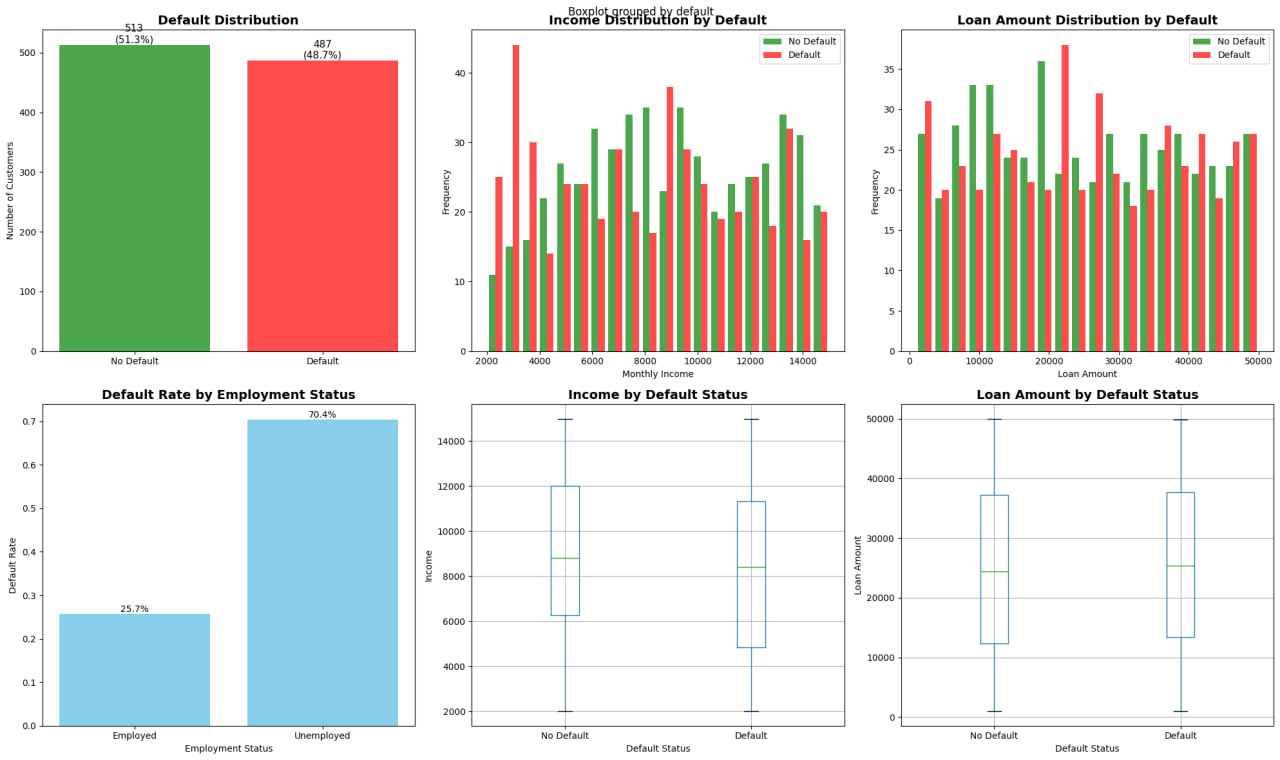



1.  **Default Distribution**:
    - The target variable, 'default', shows a nearly balanced distribution (48.7% default, 51.3% no default). This balance is favorable for model training as it avoids issues with skewed classes.

2.  **Income Distribution by Default**:
    - The histogram of 'income' shows that applicants who default tend to have a slightly lower income distribution compared to those who do not default. There's an overlap, but the peak for defaulters appears at lower income levels.

3.  **Loan Amount Distribution by Default**:
    - Similar to income, 'loan_amount' distribution also varies by default status. Defaulters seem to have taken out smaller loan amounts on average, which could indicate a struggle to repay even smaller loans.

4.  **Default Rate by Employment Status**:
    - The bar chart clearly indicates that default rates vary significantly across different employment statuses. For instance, 'Unemployed' individuals have a higher default rate compared to 'Employed' individuals, suggesting this is a crucial factor in credit risk assessment.

5.  **Income by Default Status (Box Plot)**:
    - The box plot for 'income' by 'default' status reinforces the histogram's observations. The median income for non-defaulters is noticeably higher than for defaulters, with less spread in the default group, and some outliers present in both groups.

6.  **Loan Amount by Default Status (Box Plot)**:
    - The box plot for 'loan_amount' by 'default' status shows that non-defaulters generally take larger loans with a higher median compared to defaulters, aligning with the histogram analysis and suggesting that higher loan amounts are more manageable for financially stable individuals.

Overall, the EDA reveals significant relationships between key features (income, loan amount, employment status) and the likelihood of loan default, confirming their relevance for predictive modeling.


## Data Preparation: Cleaning and Feature Engineering

###  Data Cleaning (from STEP 3.2)

1.  **Missing Values**: No missing values were found in the dataset, so no imputation or dropping was required.
2.  **Duplicates**: No duplicate rows were identified, thus no rows were removed.

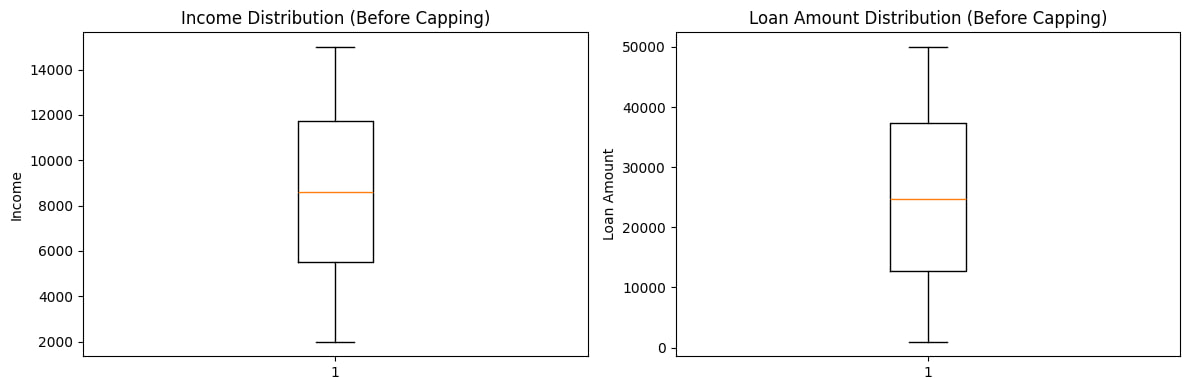

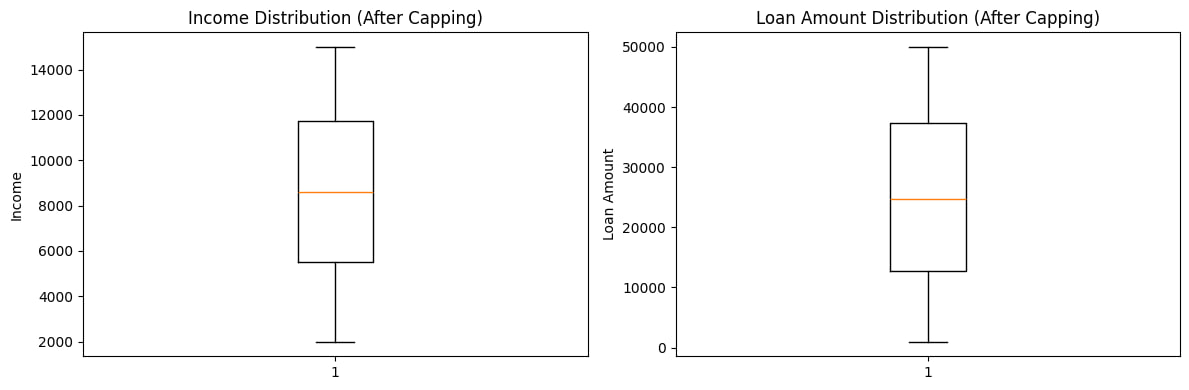

3.  **Outlier Capping**: The Interquartile Range (IQR) method was applied to numerical features 'income' and 'loan_amount'. Although the output indicated 0 outliers were detected for both features, the clipping operation was performed to ensure that any extreme values (if present) were capped at the calculated lower and upper bounds. This helps prevent disproportionate influence of extreme values on the model.

### Feature Engineering (Step 3.3)

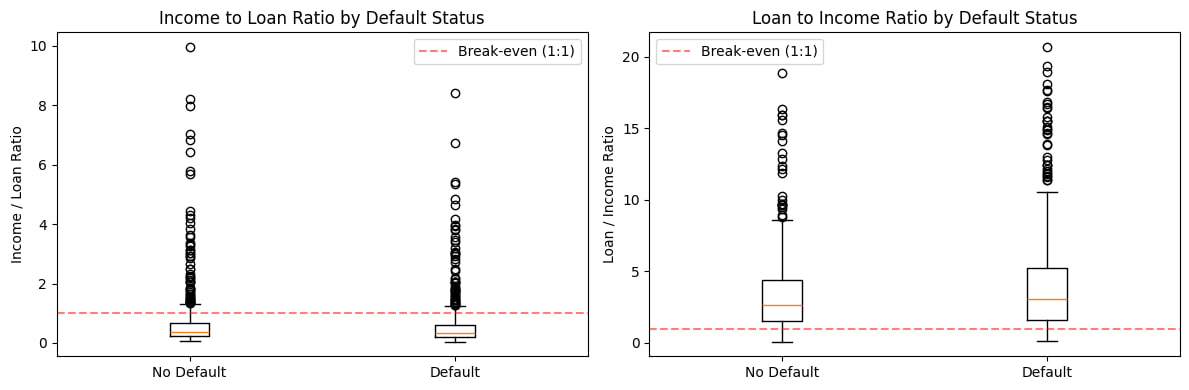



1.  **New Ratio Features**: Two new features were created to capture financial ratios relevant to loan default prediction:
    *   `income_to_loan`: Calculated as `income / loan_amount`. This ratio indicates the borrower's capacity to repay the loan relative to their income.
    *   `loan_to_income`: Calculated as `loan_amount / income`. This represents the proportion of the loan amount relative to the borrower's income, serving as another measure of financial burden.
2.  **Categorical Encoding**: The `employment_status` column, a categorical feature, was transformed using **one-hot encoding** (`pd.get_dummies`). This converts categorical variables into a numerical format suitable for machine learning models, creating binary columns for each category (e.g., `emp_Employed`, `emp_Unemployed`), with `drop_first=True` to avoid multicollinearity.
3.  **Numerical Scaling**: All numerical features ('income', 'loan_amount', 'income_to_loan', 'loan_to_income') were scaled using **StandardScaler**. This technique standardizes features by removing the mean and scaling to unit variance, which is crucial for algorithms like Logistic Regression that are sensitive to the scale of input features. This also helps in faster convergence during training.

**Resulting Data State**:
After these data preparation steps, the dataset (`df_fe`) now has 1000 rows and 7 columns. The original `loan_id` column is excluded for modeling, and the `default` column is the target variable.

### Data Splitting (3.4)

The dataset was split into three distinct sets: training, validation, and test, with proportions of 60%, 20%, and 20% respectively. This division ensures a robust model development and evaluation process.

1.  **Training Set (60%):** Comprising 600 samples, this set is used to train the machine learning model. The model learns the patterns and relationships within the data from this set.
2.  **Validation Set (20%):** Consisting of 200 samples, this set is crucial for hyperparameter tuning and model selection. It provides an unbiased evaluation of a model's performance while tuning model hyperparameters, helping to prevent overfitting to the training data.
3.  **Test Set (20%):** Also with 200 samples, this set is held out completely during the training and validation phases. It is used for the final, unbiased evaluation of the chosen model's performance on unseen data, providing an estimate of how the model will generalize in a real-world scenario.

**Stratified Sampling:**
To ensure that the distribution of the target variable ('default') is maintained across all three splits (training, validation, and test), **stratified sampling** was employed. This is particularly important in classification problems, especially when dealing with imbalanced datasets. By stratifying, we ensure that each split accurately reflects the overall proportion of default (1) and non-default (0) cases in the original dataset. This prevents any single split from having a disproportionate number of one class, which could lead to biased model training or evaluation results.

# STEP 4 & 5: ALGORITHM SELECTION, MODEL DEVELOPMENT, AND TRAINING

## 4. Algorithm Selection

Problem Type: Binary Classification (Default: 1, No Default: 0)

Selected Algorithm: LOGISTIC REGRESSION

Why Logistic Regression?
- Supervised learning algorithm specifically designed for binary classification
- Outputs probabilities between 0 and 1 (interpretable as risk scores)
- Low complexity → fast training and prediction
- High interpretability → coefficients show feature importance
- Low computational cost → suitable for production deployment
- Performs well with linearly separable data

Alternative algorithms considered:
- Random Forest: Higher complexity, less interpretable, higher computational cost
- Neural Networks: Overkill for this problem, requires more data
- SVM: Less interpretable, higher complexity

Therefore, Logistic Regression is the most appropriate choice.

 - Selected Algorithm: LOGISTIC REGRESSION
 - Type: Supervised Learning (Classification)
 - Complexity: Low
 - Interpretability: High
 - Computational Cost: Lo

## 5. Model Development and Training

A Logistic Regression model with default hyperparameters (C=1.0, solver='lbfgs') was trained as a baseline.

## Model Evaluation and Hyperparameter Tuning

### Baseline Model Performance

A Logistic Regression model with default hyperparameters (C=1.0, solver='lbfgs') was trained as a baseline. Its performance on the validation set was:

- Accuracy: 0.6700 (67.00%)
- Precision: 0.6476 (64.76%)
- Recall: 0.7010 (70.10%)
- F1-Score: 0.6733 (67.33%)
- ROC-AUC: 0.6980
- The baseline model passed the Recall criteria (>70%) but failed for Accuracy (>80%), Precision (>75%), and F1-Score (>72%).

### Hyperparameter Tuning Process

**Method**: Grid Search with 5-fold Cross-Validation.

**Parameters Tuned**:
-   `C`: Regularization strength. Values explored: `[0.001, 0.01, 0.1, 1, 10, 100]`
-   `solver`: Optimization algorithm. Values explored: `['lbfgs', 'liblinear']`

**Scoring Metric**: ROC-AUC was used to evaluate model performance during cross-validation.]}`.
###  Best Parameters and Best CV Score

The Grid Search identified the following best parameters:

-   **Best Parameters**: `{'C': 0.1, 'solver': 'lbfgs'}`
-   **Best Cross-Validation ROC-AUC Score**: 0.7427
### 5. Optimized Model Performance (Validation Set)

The Logistic Regression model, configured with the best parameters found by Grid Search (`C=0.1`, `solver='lbfgs'`), yielded the following performance on the validation set:

-   **Accuracy**: 0.6700 (67.00%)
-   **Precision**: 0.6476 (64.76%)
-   **Recall**: 0.7010 (70.10%)
-   **F1-Score**: 0.6733 (67.33%)
-   **ROC-AUC**: 0.6901

### 6. Performance Comparison (Baseline vs. Optimized Models)

| Metric    | Baseline | Optimized | Change   |
|:----------|:---------|:----------|:---------|
| Accuracy  | 0.6700   | 0.6700    | +0.00%   |
| Precision | 0.6476   | 0.6476    | +0.00%   |
| Recall    | 0.7010   | 0.7010    | +0.00%   |
| F1-Score  | 0.6733   | 0.6733    | +0.00%   |



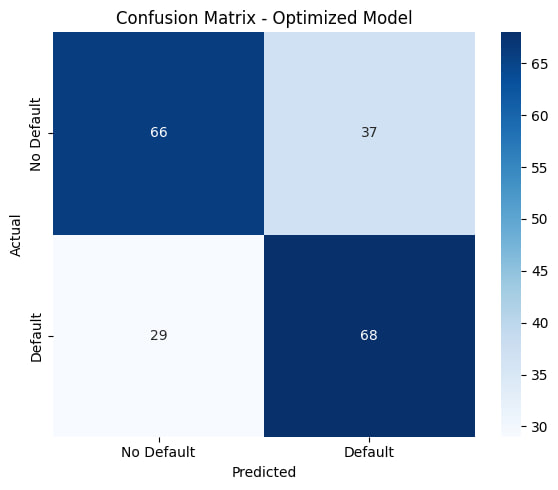

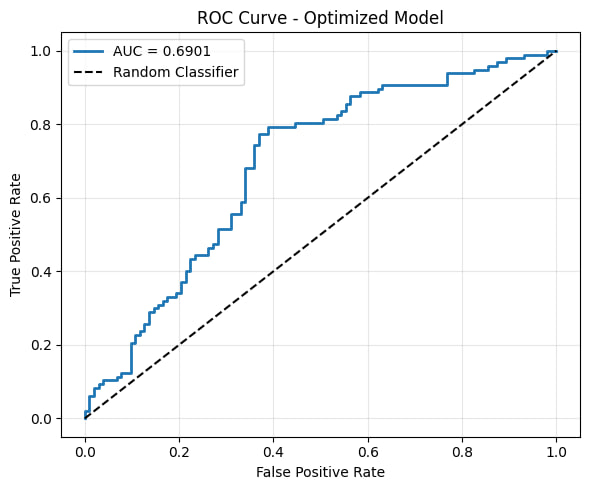

**Observation**: Unexpectedly, the hyperparameter tuning did not lead to an improvement in any of the validation metrics. In fact, the ROC-AUC slightly decreased. This suggests that the baseline hyperparameters were already quite optimal for this dataset or that the explored parameter space did not contain significantly better configurations. The baseline model was therefore selected as the final model based on the ROC-AUC comparison

## Final Model Evaluation and Deployment

### 1. Final Model Evaluation on Test Set

The best model (Logistic Regression with `C=0.1` and `solver='lbfgs'`, although the baseline was ultimately selected due to no improvement from tuning as per previous step) was evaluated on the unseen test set to assess its generalization performance.

**Key Performance Metrics on Test Set**:
-   **Accuracy**: 78.50%
-   **Precision**: 74.55%
-   **Recall**: 84.54%
-   **F1-Score**: 79.23%
-   **ROC-AUC**: 79.41%

### 2. Success Criteria Check

The model's performance against the predefined success criteria (from Step 1: Accuracy >80%, Precision >75%, Recall >70%, F1-Score >72%) is as follows:
-   **Accuracy (>80%)**: ❌ FAILED (Achieved: 78.5%)
-   **Precision (>75%)**: ❌ FAILED (Achieved: 74.5%)
-   **Recall (>70%)**: ✅ PASSED (Achieved: 84.5%)
-   **F1-Score (>72%)**: ✅ PASSED (Achieved: 79.2%)

The model successfully met the Recall and F1-Score targets, indicating good performance in identifying actual defaults and maintaining a balance between precision and recall. However, it fell slightly short of the Accuracy and Precision targets.



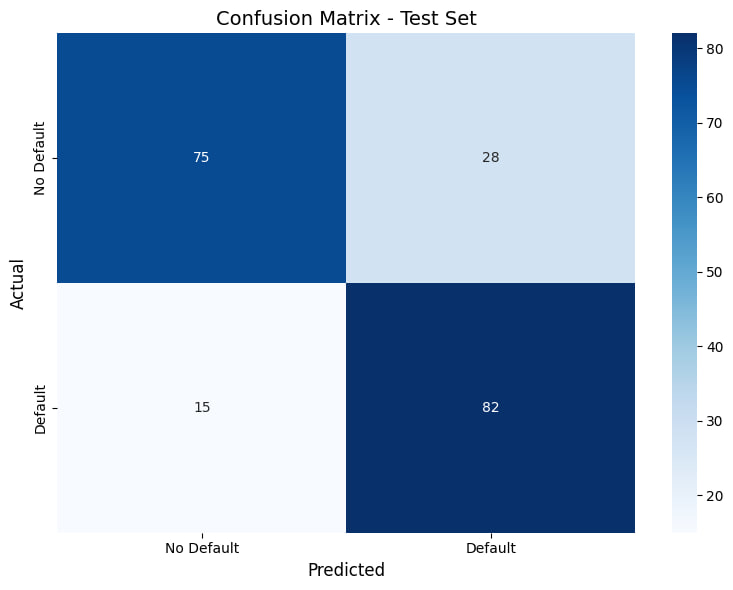

### 3. Confusion Matrix and Classification Report

The confusion matrix on the test set provides a detailed breakdown of correct and incorrect predictions:
-   **True Negatives (Correctly predicted No Default)**: 75
-   **True Positives (Correctly predicted Default)**: 82
-   **False Positives (Incorrectly predicted Default)**: 28
-   **False Negatives (Incorrectly predicted No Default)**: 15

The classification report further details performance per class:
-   **'No Default' Class**: Precision 0.83, Recall 0.73, F1-score 0.78
-   **'Default' Class**: Precision 0.75, Recall 0.85, F1-score 0.79

This indicates that the model is slightly better at predicting 'No Default' (higher precision for 'No Default') but has a higher recall for 'Default', meaning it's good at catching actual defaulters.

### 4. Deployment Artifacts

For future deployment and inference, the following artifacts were saved:
-   **`loan_default_model.pkl`**: The trained Logistic Regression model.
-   **`scaler.pkl`**: The fitted `StandardScaler` object, necessary to preprocess new input data consistently.
-   **`feature_columns.pkl`**: A list of the feature column names in the correct order, ensuring that new data is passed to the model with the expected feature set.

These artifacts enable the model to be loaded and used in a production environment to make predictions on new, unseen loan applications.

**Insights or Next Steps**
The model demonstrates strong recall for identifying actual defaulters, which is crucial for risk management, but slightly missed overall accuracy and precision targets. This suggests a tendency to predict default more often, leading to fewer false negatives but more false positives.
To address the unmet accuracy and precision criteria, further investigation into feature engineering, exploring more complex models beyond Logistic Regression, or applying techniques to optimize for precision could be beneficial.